<a href="https://colab.research.google.com/github/muhammadomer203-coder/Supply-Chain-Analytics/blob/main/00-Initial%20Working/00_Initial_Working.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
print("Setup Working:",pd.__version__)

Setup Working: 2.2.3


### Supply Chain Analytics: Top 5 Plants by PO Value

To analyze the Purchase Order (PO) values from your uploaded Excel sheet, please follow these steps:

1.  **Upload your Excel file**: Make sure your Excel file is uploaded to your Colab environment. If it's in Google Drive, you might need to mount your Drive first.
2.  **Update the file path**: In the code below, replace `'your_excel_file_name.xlsx'` with the actual name of your uploaded Excel file.
3.  **Run the cells**: Execute the code cells sequentially to load, clean, analyze, and visualize your data.

In [ ]:
import pandas as pd
# Step 1: Data Loading
# Replace 'your_excel_file_name.xlsx' with the actual path to your Excel file.
# For example, if you uploaded 'po_data.xlsx' to your Colab session, use 'po_data.xlsx'.
# If it's in a specific folder, provide the full path (e.g., 'data/po_data.xlsx').
try:
    # Reading from the 'Procurement_Data' worksheet (case-sensitive)
    df = pd.read_excel('Chenab_Motors_Procurement_Practice_Dataset.xlsx', sheet_name='Procurement_Data')
    print("Data loaded successfully. First 5 rows:")
    display(df.head())
    print("\nData Info:")
    df.info()
except FileNotFoundError:
    print("Error: The file 'Chenab_Motors_Procurement_Practice_Dataset.xlsx' was not found. Please upload the file and update the file name in the code.")
except Exception as e:
    print(f"An error occurred during data loading: {e}")

Data loaded successfully. First 5 rows:


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   PO Number                  10050 non-null  object        
 1   PO Line Item               10050 non-null  int64         
 2   Vendor ID                  10050 non-null  object        
 3   Vendor                     9930 non-null   object        
 4   Plant                      10050 non-null  object        
 5   Department                 10050 non-null  object        
 6   Cost Center                9929 non-null   object        
 7   Requisitioner              10050 non-null  object        
 8   Material Group             9927 non-null   object        
 9   Quantity                   10050 non-null  int64         
 10  Unit Price (PKR)           10050 non-null  int64         
 11  PO Value (PKR)             10050 non-null  float64     

In [ ]:
# Step 2: Data Cleaning
# Ensure 'PO Value' is a numeric type and 'Plant' is a string type.
# Handle missing values if any.

# Standardize column names for easier access (optional but good practice)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Check if 'po_value_(pkr)' and 'plant' columns exist
if 'po_value_(pkr)' not in df.columns:
    print("Error: 'PO Value (PKR)' column not found after standardization. Please check your Excel file's column names.")
    print(f"Available columns: {df.columns.tolist()}")
elif 'plant' not in df.columns:
    print("Error: 'Plant' column not found after standardization. Please check your Excel file's column names.")
    print(f"Available columns: {df.columns.tolist()}")
else:
    # Convert 'po_value_(pkr)' to numeric, coercing errors to NaN
    df['po_value_(pkr)'] = pd.to_numeric(df['po_value_(pkr)'], errors='coerce')

    # Drop rows where 'po_value_(pkr)' is NaN (if conversion failed or was missing)
    initial_rows = len(df)
    df.dropna(subset=['po_value_(pkr)'], inplace=True)
    if len(df) < initial_rows:
        print(f"Dropped {initial_rows - len(df)} rows with invalid or missing 'PO Value (PKR)'.")

    # Fill missing 'plant' values with 'Unknown'
    df['plant'] = df['plant'].fillna('Unknown') # Addressing FutureWarning by not using inplace=True directly on chained assignment
    print("\nData cleaning complete. Displaying info after cleaning:")
    df.info()


Data cleaning complete. Displaying info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   po_number                  10050 non-null  object        
 1   po_line_item               10050 non-null  int64         
 2   vendor_id                  10050 non-null  object        
 3   vendor                     9930 non-null   object        
 4   plant                      10050 non-null  object        
 5   department                 10050 non-null  object        
 6   cost_center                9929 non-null   object        
 7   requisitioner              10050 non-null  object        
 8   material_group             9927 non-null   object        
 9   quantity                   10050 non-null  int64         
 10  unit_price_(pkr)           10050 non-null  int64         
 11  po_value_(

In [ ]:
# Step 3: Calculations - Find top 5 plants by PO value

# Group by 'plant' and sum the 'po_value_(pkr)'
plant_po_value = df.groupby('plant')['po_value_(pkr)'].sum().reset_index()

# Sort in descending order to get the top plants
top_5_plants = plant_po_value.sort_values(by='po_value_(pkr)', ascending=False).head(5)

print("\nTop 5 Plants by Total PO Value:")
display(top_5_plants)


Top 5 Plants by Total PO Value:


,plant,po_value_(pkr)
1,Karachi Plant,2.454660e+08
2,Lahore Plant,1.447569e+08
0,Faisalabad Plant,9.624078e+07
3,Multan Plant,8.029773e+07
4,Peshawar Plant,4.790866e+07


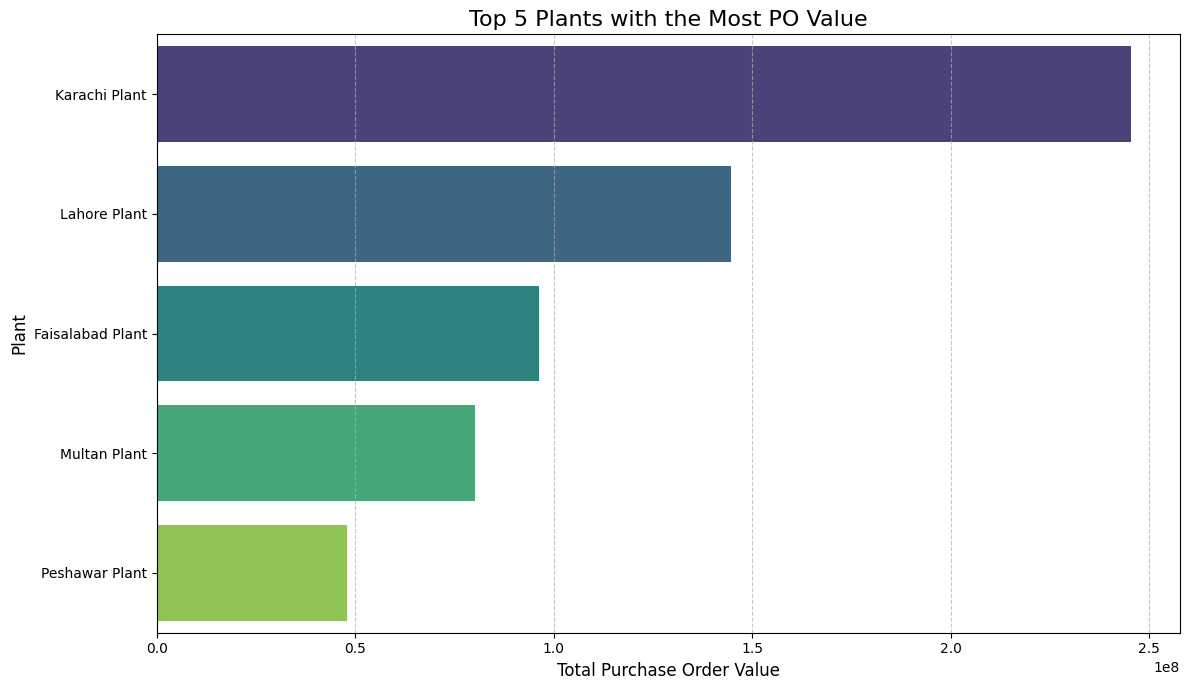

In [ ]:
# Step 4: Visualization - Clearly labeled bar chart for top 5 plants
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='po_value_(pkr)', y='plant', hue='plant', data=top_5_plants, palette='viridis', legend=False)
plt.title('Top 5 Plants with the Most PO Value', fontsize=16)
plt.xlabel('Total Purchase Order Value', fontsize=12)
plt.ylabel('Plant', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Final Summary Table
# The 'top_5_plants' DataFrame already serves as the summary table.
print("\n--- Final Summary Table ---")
display(top_5_plants)
print("\nThis table shows the top 5 plants ranked by their total Purchase Order Value, providing key insights into which plant contributes most significantly to the total PO value.")


--- Final Summary Table ---


NameError: name 'top_5_plants' is not defined

### Additional Procurement Metrics

In [ ]:
# Step 6: Calculate additional procurement metrics

# Total PO Spend (sum of 'po_value_(pkr)')
total_po_spend = df['po_value_(pkr)'].sum()

# Total Number of POs (count of unique 'po_number')
total_pos = df['po_number'].nunique()

# Total Number of Vendors (count of unique 'vendor_id')
total_vendors = df['vendor_id'].nunique()

# Average PO Value (Total PO Spend / Total Number of POs)
# Check for division by zero
average_po_value = total_po_spend / total_pos if total_pos > 0 else 0

# Average Line-Item Value (Total PO Spend / Total number of line items)
# Assuming each row in the DataFrame represents a line item
total_line_items = len(df)
average_line_item_value = total_po_spend / total_line_items if total_line_items > 0 else 0

# Display the calculated metrics
print(f"\nTotal PO Spend: {total_po_spend:,.2f} PKR")
print(f"Total Number of POs: {total_pos}")
print(f"Total Number of Vendors: {total_vendors}")
print(f"Average PO Value: {average_po_value:,.2f} PKR")
print(f"Average Line-Item Value: {average_line_item_value:,.2f} PKR")


Total PO Spend: 614,670,044.11 PKR
Total Number of POs: 7406
Total Number of Vendors: 60
Average PO Value: 82,996.23 PKR
Average Line-Item Value: 61,161.20 PKR


### Top 10 Vendors by Total PO Value

In [ ]:
# Step 7: Identify top 10 vendors by total PO Value

# Group by 'vendor' and sum the 'po_value_(pkr)'
vendor_po_value = df.groupby('vendor')['po_value_(pkr)'].sum().reset_index()

# Sort in descending order to get the top vendors
top_10_vendors = vendor_po_value.sort_values(by='po_value_(pkr)', ascending=False).head(10)

print("\nTop 10 Vendors by Total PO Value:")
display(top_10_vendors)


Top 10 Vendors by Total PO Value:


,vendor,po_value_(pkr)
0,Al-Amin Auto Components,1.018835e+08
27,Karachi Steel Traders,5.007253e+07
59,Zaman Brothers Trading,3.586614e+07
5,Anwar Electric Works,3.146678e+07
54,TCS Cargo Services,2.703754e+07
21,Gulistan Logistics,1.972002e+07
51,Speedline Logistics,1.750654e+07
49,Sindh Spinners Co.,1.655498e+07
56,United Rubber Industries,1.587658e+07
31,Modern Fasteners Co.,1.338250e+07


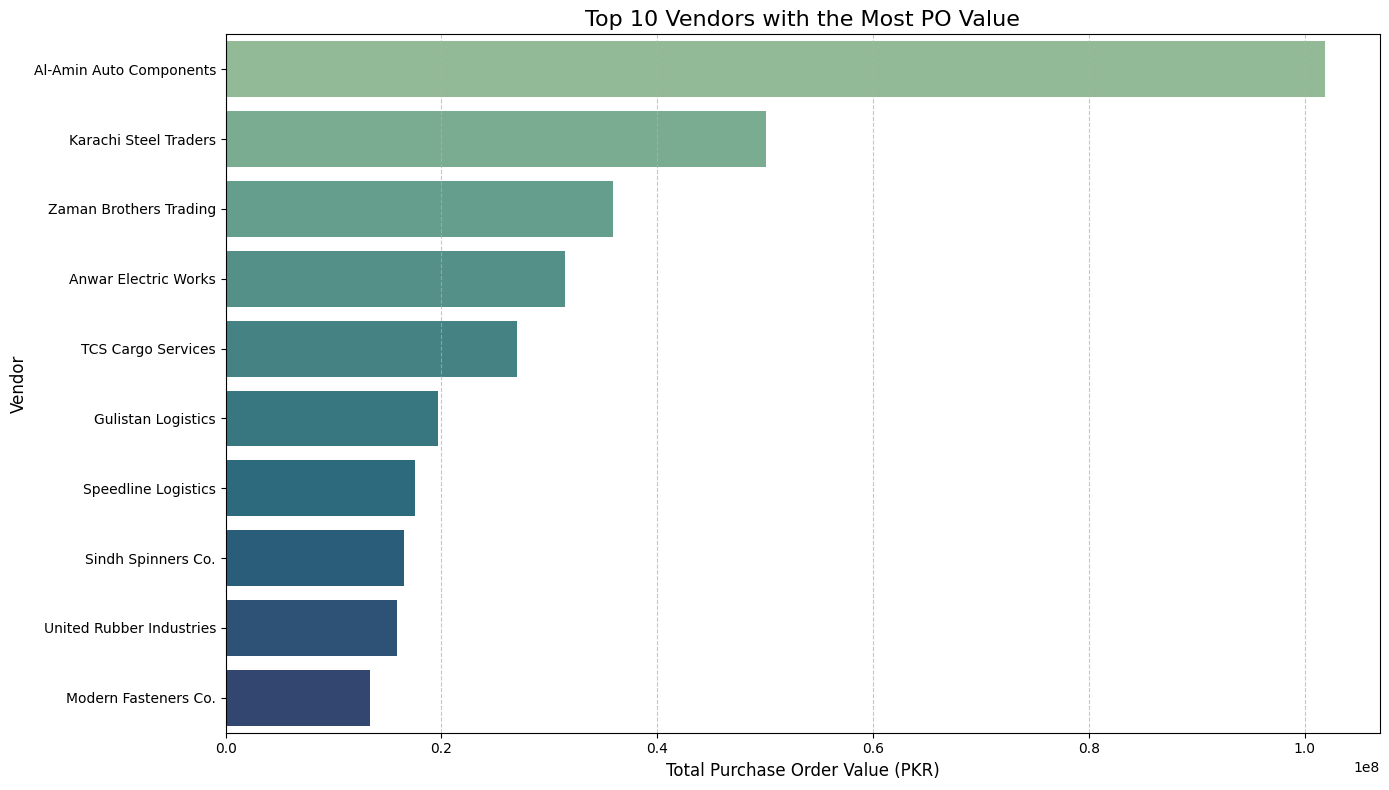

In [ ]:
# Step 8: Visualization - Bar chart for top 10 vendors
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.barplot(x='po_value_(pkr)', y='vendor', hue='vendor', data=top_10_vendors, palette='crest', legend=False)
plt.title('Top 10 Vendors with the Most PO Value', fontsize=16)
plt.xlabel('Total Purchase Order Value (PKR)', fontsize=12)
plt.ylabel('Vendor', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Orders per Month

In [ ]:
# Step 9: Analyze orders per month

# Ensure 'creation_date' is in datetime format
df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

# Drop rows where 'creation_date' could not be parsed
df.dropna(subset=['creation_date'], inplace=True)

# Extract month and year from the 'creation_date'
df['month_year'] = df['creation_date'].dt.to_period('M')

# Group by month and count unique PO numbers
orders_per_month = df.groupby('month_year')['po_number'].nunique().reset_index()

# Rename columns for clarity
orders_per_month.columns = ['Month', 'Number of Unique POs']

# Convert 'Month' back to string for better display if needed, or keep as Period
orders_per_month['Month'] = orders_per_month['Month'].astype(str)

print("\nNumber of Unique Purchase Orders per Month:")
display(orders_per_month)


Number of Unique Purchase Orders per Month:


,Month,Number of Unique POs
0,2024-02,1
1,2024-03,522
2,2024-04,487
3,2024-05,416
4,2024-06,544
5,2024-07,384
6,2024-08,360
7,2024-09,357
8,2024-10,384
9,2024-11,332


### Monthly Total PO Value

In [ ]:
# Step 10: Calculate Monthly Total PO Value

# Group by 'month_year' and sum the 'po_value_(pkr)'
monthly_po_value = df.groupby('month_year')['po_value_(pkr)'].sum().reset_index()

# Rename columns for clarity
monthly_po_value.columns = ['Month', 'Total Monthly PO Value']

# Convert 'Month' back to string for better display
monthly_po_value['Month'] = monthly_po_value['Month'].astype(str)

print("\nTotal Monthly Purchase Order Value:")
display(monthly_po_value.head())


Total Monthly Purchase Order Value:


,Month,Total Monthly PO Value
0,2024-02,2.943500e+04
1,2024-03,4.127004e+07
2,2024-04,4.186131e+07
3,2024-05,3.647153e+07
4,2024-06,4.281519e+07


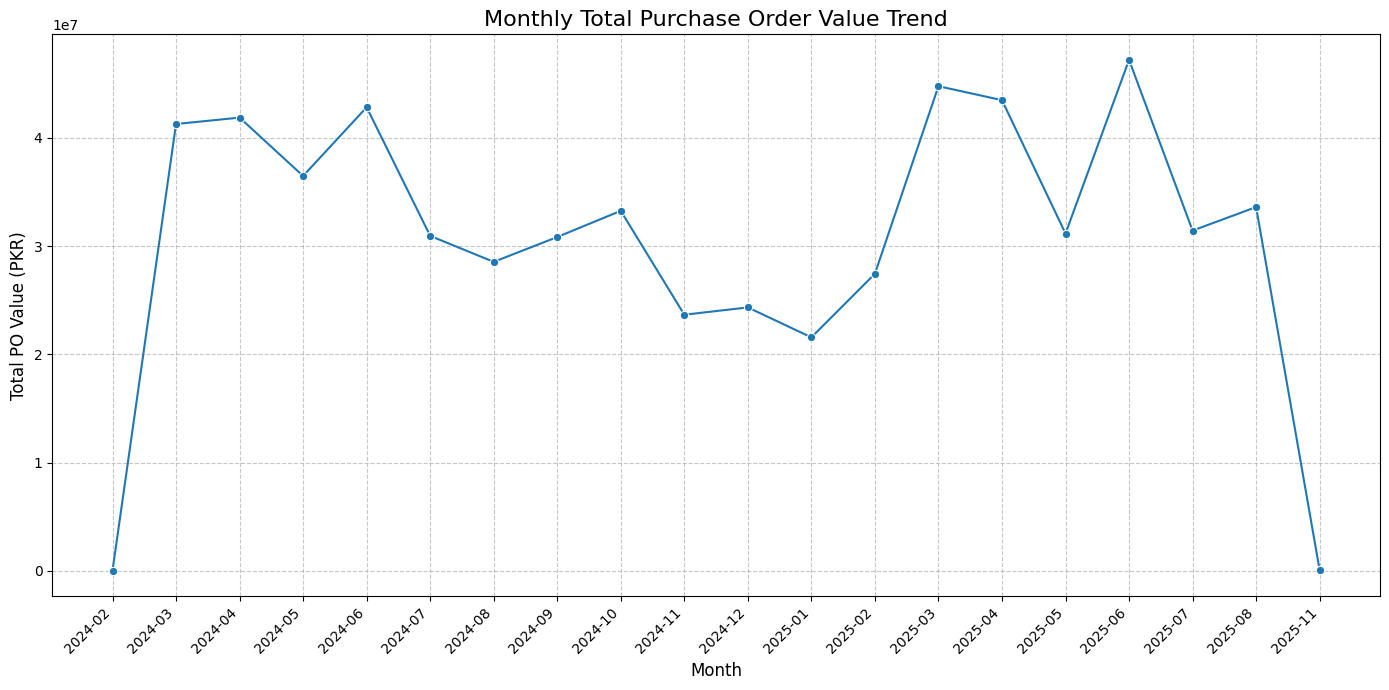

In [ ]:
# Step 11: Visualization - Line chart for monthly PO value trends
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Convert 'Month' column to datetime objects for proper chronological sorting on the x-axis
monthly_po_value['Month_dt'] = pd.to_datetime(monthly_po_value['Month'])
monthly_po_value_sorted = monthly_po_value.sort_values(by='Month_dt')

sns.lineplot(x='Month', y='Total Monthly PO Value', data=monthly_po_value_sorted, marker='o')
plt.title('Monthly Total Purchase Order Value Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total PO Value (PKR)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()